# 2 · ESRS-RAG — Generation evaluation

The second half of the RAG. Notebook 1 asked *"does retrieval find the right paragraphs?"*; this one
asks *"does the model answer well **and know when to stay silent**?"* — measured on the **same 45
hand-verified questions**, with a **local LLM** (`llama3.2:3b`, `temperature = 0`), 100% on-premise.

> This is a results notebook. The pipeline (retrieval → prompt → local LLM) lives outside it; here we
> only read precomputed results. The pipeline is **frozen**: answers are generated once and the
> metrics are **not** re-tuned on them (the prompt was tuned on a throwaway dev set, never on the
> eval set — the same "don't touch the test set" discipline as a forecasting baseline).

In [1]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
%config InlineBackend.figure_format = 'retina'

def _carga(nombre):
    for _cand in (f"eval/{nombre}", f"../eval/{nombre}"):
        if Path(_cand).exists():
            return json.loads(Path(_cand).read_text(encoding="utf-8"))

G = _carga("generacion_resultados.json")
KSWEEP = _carga("barrido_k.json")        # barrido de k (contexto que ve el LLM)

# --- paleta semántica (misma familia que el notebook 1) ---
OK, BAD, ABS, GREY = "#1baf7a", "#eb6834", "#2a78d6", "#8a8a86"
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e5e5e2"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "figure.facecolor": "white",
    "font.size": 9, "axes.titlesize": 11, "axes.labelsize": 9,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5, "legend.fontsize": 8.5,
    "axes.edgecolor": INK2, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.spines.top": False, "axes.spines.right": False,
})

def _limpia(ax, titulo, ylabel=None, ymax=None):
    ax.set_title(titulo, fontsize=11, fontweight="normal", loc="left", pad=8)
    if ylabel: ax.set_ylabel(ylabel)
    ax.yaxis.grid(True, color=GRID, lw=1); ax.set_axisbelow(True)
    if ymax: ax.set_ylim(0, ymax)

T = G["titulares"]
def pct(k): return T[k]["pct"]
def frac(k): return f"{T[k]['num']}/{T[k]['den']}"
print(f"Loaded: {G['meta']['n_preguntas']} questions · model {G['meta']['modelo']} "
      f"(temp={G['meta']['temperature']}) · corpus {G['meta']['idioma_corpus'].upper()}")

Loaded: 45 questions · model llama3.2:3b (temp=0) · corpus ES


## The core metric: the faithfulness ↔ answer-rate trade-off

A RAG can fail in two opposite ways, and **one number hides the other**:

- **Too cautious** — say *"I don't know"* to everything. It never hallucinates and scores a perfect
  **1.0 on faithfulness** — and is **useless**. This was literally the earlier demo: **0 % answer rate**.
- **Too eager** — always answer, even when the corpus has nothing to say → it **hallucinates**.

So faithfulness *alone* is a **degenerate metric** (a system that abstains on everything maximises
it). The only honest measurement tracks **both** at once — the answer rate *and* the hallucination
rate — which is possible only because the eval set contains **both** answerable questions **and**
out-of-corpus ones. It is the POD/FAR/CSI logic of a weather model: no single score is "the" score.

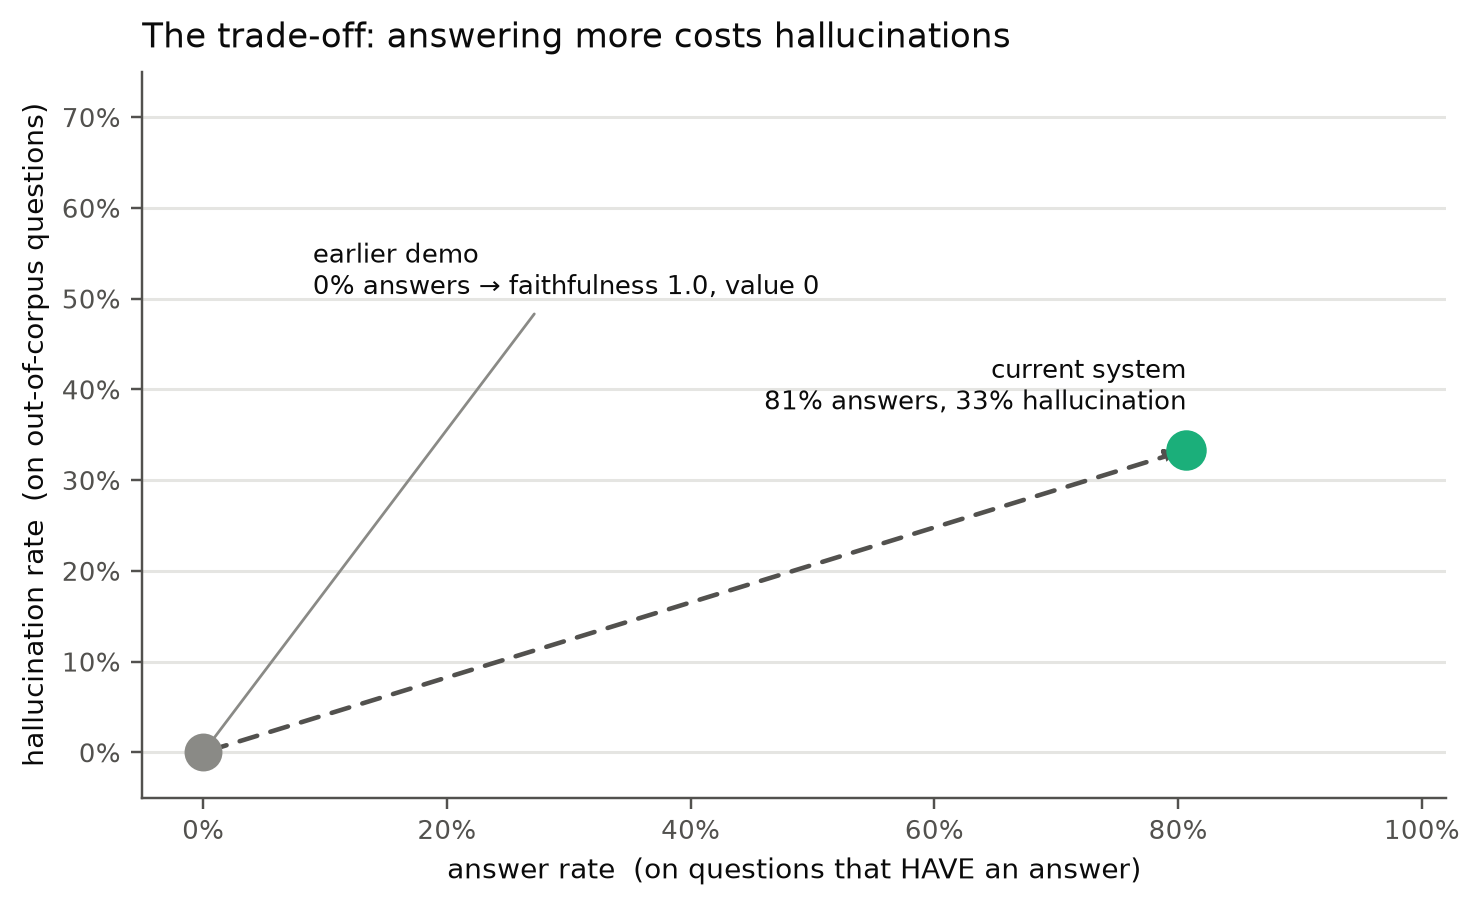

In [2]:
demo, now = G["demo_vs_ahora"]["demo"], G["demo_vs_ahora"]["ahora"]
dx, dy = 100*demo["tasa_respuesta"], 100*demo["alucinacion"]
nx, ny = 100*now["tasa_respuesta"],  100*now["alucinacion"]
fig, ax = plt.subplots(figsize=(6.8, 4.2))
# el espacio del trade-off: eje x = tasa de respuesta, eje y = alucinación
ax.annotate("", xy=(nx, ny), xytext=(dx, dy),
            arrowprops=dict(arrowstyle="-|>", color=INK2, lw=1.5, ls=(0, (4, 3))))
ax.scatter([dx], [dy], s=130, color=GREY, zorder=3)
ax.scatter([nx], [ny], s=150, color=OK, zorder=3)
# La etiqueta de la demo se lleva a la ZONA VACÍA de arriba a la izquierda y se
# ata al punto con una línea fina: pegada al punto se montaba sobre la flecha.
ax.annotate("earlier demo\n0% answers → faithfulness 1.0, value 0",
            xy=(dx, dy), xytext=(9, 53), fontsize=8.5, color=INK, va="center",
            arrowprops=dict(arrowstyle="-", color=GREY, lw=0.9,
                            shrinkA=2, shrinkB=6))
ax.text(nx, ny+3.5, f"current system\n{nx:.0f}% answers, {ny:.0f}% hallucination",
        fontsize=8.5, color=INK, ha="right", va="bottom")
_limpia(ax, "The trade-off: answering more costs hallucinations")
ax.set_xlabel("answer rate  (on questions that HAVE an answer)")
ax.set_ylabel("hallucination rate  (on out-of-corpus questions)")
ax.set_xlim(-5, 102); ax.set_ylim(-5, 75)
ax.xaxis.set_major_formatter(PercentFormatter(100, decimals=0))
ax.yaxis.set_major_formatter(PercentFormatter(100, decimals=0))
plt.tight_layout(); plt.show()

## Both question families, measured separately

The eval set has two families, and each has its **own** notion of "correct":

- **Answerable** questions (`requisito`, `definicion`, `factual`, `factual_numerica`) → the system
  should **answer**. Abstaining here is **cowardice** (the demo's failure).
- **Out-of-corpus** questions (`fuera_de_corpus`) → the system should **abstain**. Answering here is
  **hallucination**.

Reading them together is the whole point: high answer rate is only good if hallucination is low, and
vice-versa.

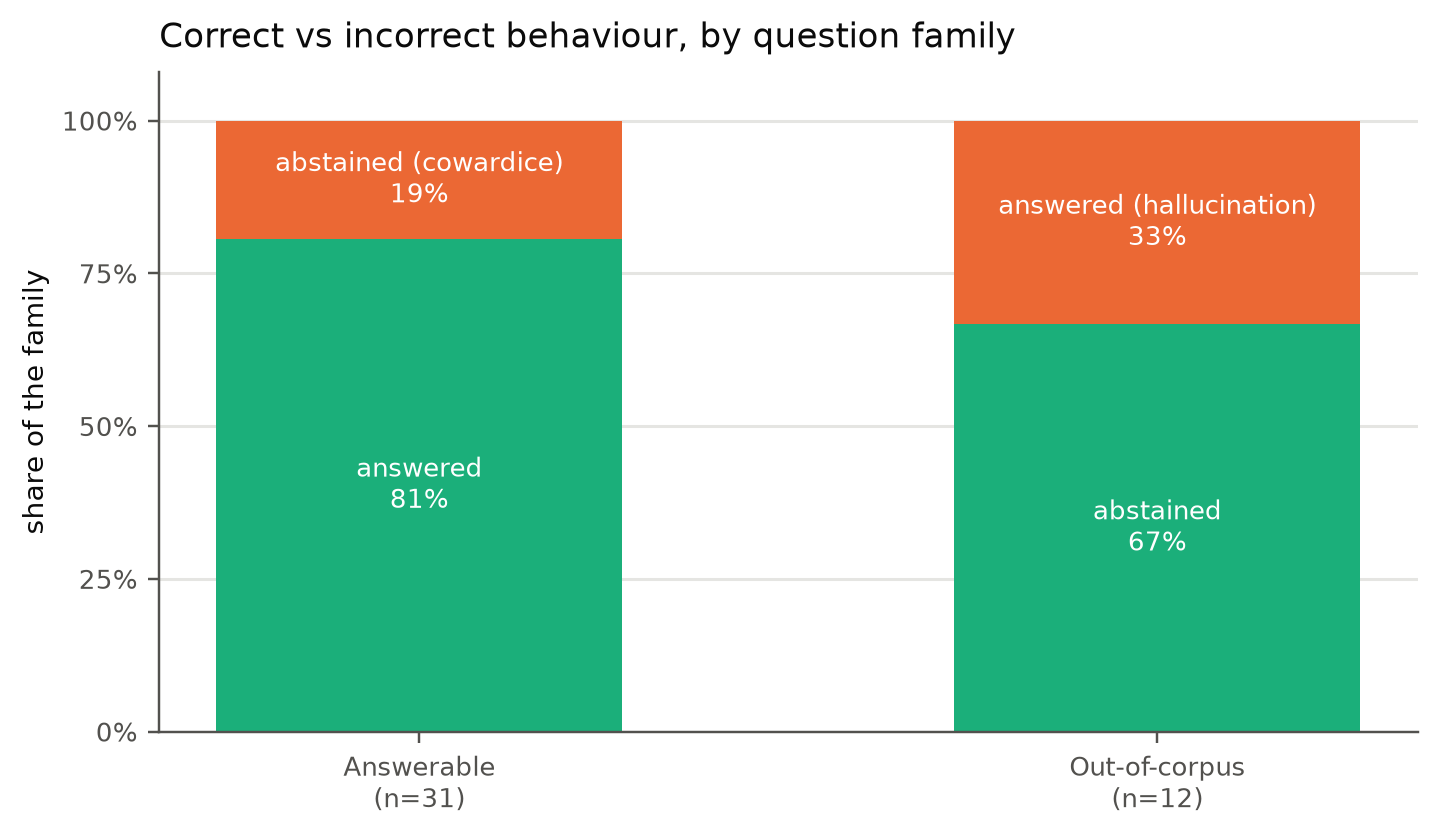

green = correct behaviour for that family · orange = the failure mode for that family


In [3]:
fam = [
    ("Answerable\n(n=%d)" % T["tasa_respuesta"]["den"],
     pct("tasa_respuesta"), pct("cobardia"), "answered", "abstained (cowardice)"),
    ("Out-of-corpus\n(n=%d)" % T["abstencion"]["den"],
     pct("abstencion"), pct("alucinacion"), "abstained", "answered (hallucination)"),
]
fig, ax = plt.subplots(figsize=(6.6, 3.9))
for i, (lab, good, bad, gl, bl) in enumerate(fam):
    good, bad = 100*good, 100*bad
    ax.bar(i, good, 0.55, color=OK)
    ax.bar(i, bad, 0.55, bottom=good, color=BAD)
    ax.text(i, good/2, f"{gl}\n{good:.0f}%", ha="center", va="center", color="white", fontsize=8.5)
    ax.text(i, good+bad/2, f"{bl}\n{bad:.0f}%", ha="center", va="center", color="white", fontsize=8.5)
ax.set_xticks(range(len(fam))); ax.set_xticklabels([f[0] for f in fam])
_limpia(ax, "Correct vs incorrect behaviour, by question family", "share of the family", 108)
ax.set_yticks([0, 25, 50, 75, 100])
ax.yaxis.set_major_formatter(PercentFormatter(100, decimals=0))
plt.tight_layout(); plt.show()
print("green = correct behaviour for that family · orange = the failure mode for that family")

### Where the system stays silent, by type

The abstention rate per type is a sanity check on the two families above: it should be **high on
`fuera_de_corpus`** and **near zero on the answerable types**. It mostly is — the residual abstention
on answerable types is the 19 % cowardice, and the residual *non*-abstention on `fuera_de_corpus` is
the hallucination. `error_de_categoria` sits apart: the correct behaviour there is neither to abstain
nor to answer, but to **reframe** ("the standard says what to *disclose*, not what to *do*").

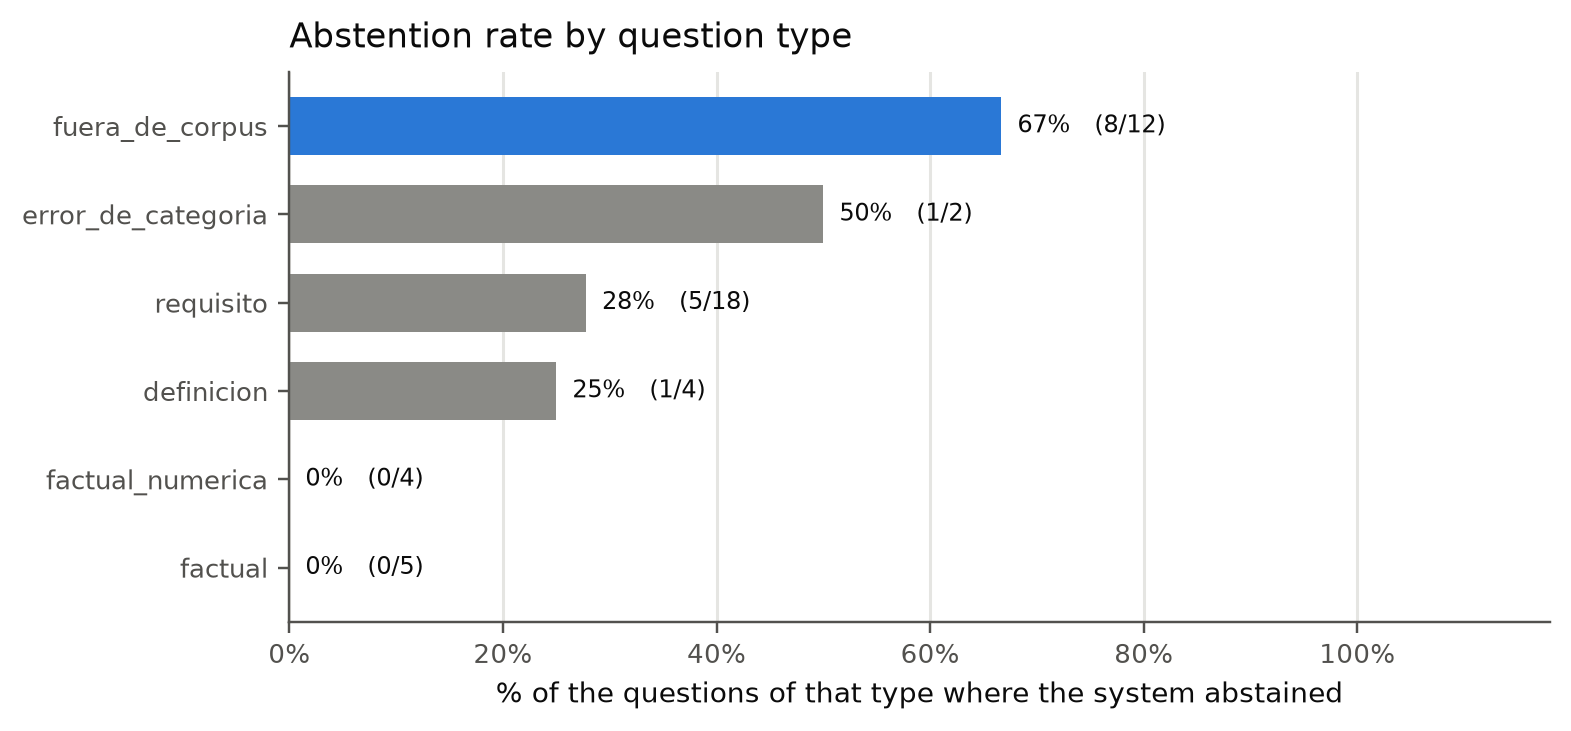

In [4]:
apt = G["abstencion_por_tipo"]
orden = sorted(apt, key=lambda t: apt[t]["pct"])
fig, ax = plt.subplots(figsize=(7.2, 3.4))
cols = [ABS if t == "fuera_de_corpus" else GREY for t in orden]
b = ax.barh(orden, [100*apt[t]["pct"] for t in orden], color=cols, height=0.66)
for bar, t in zip(b, orden):
    ax.text(bar.get_width()+1.5, bar.get_y()+bar.get_height()/2,
            f"{100*apt[t]['pct']:.0f}%   ({apt[t]['num']}/{apt[t]['den']})",
            va="center", fontsize=8, color=INK)
_limpia(ax, "Abstention rate by question type")
ax.set_xlabel("% of the questions of that type where the system abstained")
ax.xaxis.grid(True, color=GRID, lw=1); ax.yaxis.grid(False); ax.set_xlim(0, 118)
ax.xaxis.set_major_formatter(PercentFormatter(100, decimals=0))
plt.tight_layout(); plt.show()

## Failure modes a single score would hide

These came out of **reading the 45 answers by hand** against the source paragraphs — not from any
automatic metric. Each is a distinct way the system can be wrong, and each is invisible to a bare
accuracy number:

| failure mode | example | why it matters |
|---|---|---|
| **Faithful but incomplete** | Q1 lists only the *acute* climate hazards (storms, floods…) and drops the whole *chronic* half | a 100 %-faithful answer can still be useless → faithfulness alone is degenerate |
| **Fidelity to noise** | Q33 weaves in *"forced labour"* — pulled from an **irrelevant** retrieved chunk, not invented | the fault is *upstream* (a bad retrieval slot), and a naive "hallucination" label would misread it |
| **A correct answer masking a retrieval miss** | Q4 defines *own workforce* almost verbatim — but the defining paragraph was **never retrieved**; the model knew it from pre-training | the single strongest reason to measure retrieval and generation **separately** |
| **The same miss, made visible** | Q11 retrieved the *wrong* paragraph and answered from it (wrong) — same miss as Q4, but no lucky prior | luck is the only difference between Q4 and Q11 |
| **The confident legal ruling** | Q29: *"No, it is not obligated"* — a determination the corpus **cannot** make (scope is set by an external Directive) | the "confidently wrong" system the eval set was built to catch |

The Q4 vs Q11 pair is the clearest lesson: **the same retrieval failure produced a right answer in
one case and a wrong one in the other**. If you only looked at the final answer, you would call the
retrieval healthy in Q4 — and be wrong.

## How much context? The `k` sweep

`k` is how many retrieved paragraphs are pasted into the prompt. It is easy to assume more is
better — on **retrieval** it literally cannot hurt, since `recall@k` only rises as the cut-off moves
down the ranking. On **generation** it can, and does: past a point the answer is buried in
irrelevant paragraphs and the model starts quoting the wrong one.

That makes the two stages pull in opposite directions, and the sweep shows the resulting
**inverted U** most sharply on the numeric questions — the ones with a single correct figure, gradable
by string match without a judge:

- **`k` = 2–3** — answer rate stalls at 74 %: the right paragraph often isn't in the prompt at all.
- **`k` = 5–10** — the plateau. Answer rate 84 %, and numeric accuracy peaks at 4/4.
- **`k` = 20** — numeric accuracy collapses to 1/4. Not by chance: with twenty paragraphs in view the
  model answers *"three years"* instead of *"2030"*, and invents a *"50 %"* reduction that is
  nowhere in the context. The paragraph is still retrieved — it is the **reading** that fails.

**`k` = 8 was frozen**: the lower edge of the plateau, and the point where a question whose figure
sits at rank 6–8 finally makes it into the prompt. Deltas *within* the plateau are inside the noise
floor described below and are not claimed as improvements.

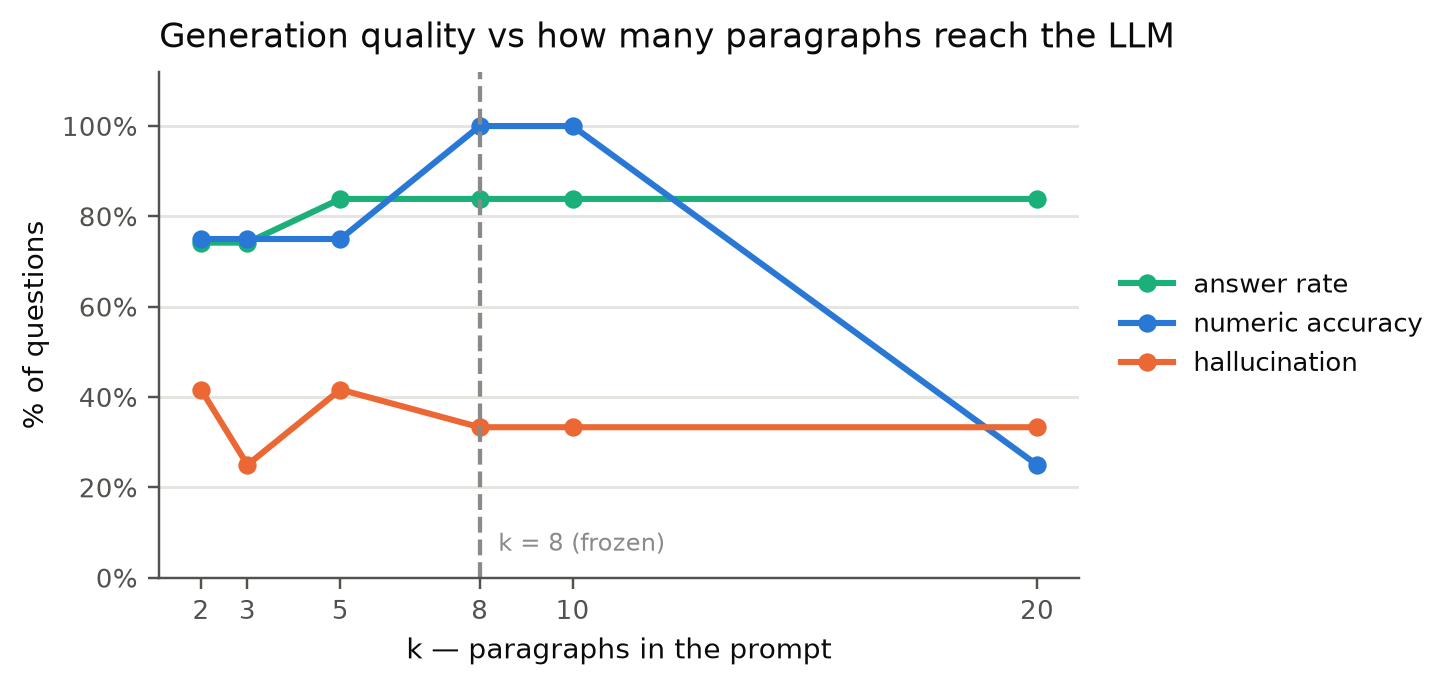

numeric accuracy is over 4 questions — the shape is the finding, not the exact rate


In [5]:
ks = sorted(KSWEEP["por_k"], key=int)
x = [int(k) for k in ks]
fig, ax = plt.subplots(figsize=(8.4, 3.2))
for clave, etq, col in [("tasa_respuesta", "answer rate", OK),
                        ("acierto_numerico", "numeric accuracy", ABS),
                        ("alucinacion", "hallucination", BAD)]:
    ax.plot(x, [100*KSWEEP["por_k"][k][clave] for k in ks], "-o", lw=2, ms=5,
            color=col, label=etq)
ax.axvline(8, color=GREY, lw=1.4, ls="--")
ax.text(8.4, 6, "k = 8 (frozen)", color=GREY, fontsize=8)
_limpia(ax, "Generation quality vs how many paragraphs reach the LLM",
        "% of questions", 112)
ax.yaxis.set_major_formatter(PercentFormatter(100, decimals=0))
ax.set_xlabel("k — paragraphs in the prompt"); ax.set_xticks(x)
# Leyenda FUERA del área de dibujo: dentro chocaba con la anotación de k=8.
ax.legend(frameon=False, fontsize=8.5, loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout(rect=(0, 0, 0.80, 1)); plt.show()
print("numeric accuracy is over 4 questions — the shape is the finding, not the exact rate")

## Method & honesty

- **Frozen pipeline, measured once.** `temperature = 0` (the generation equivalent of a fixed seed),
  and the prompt was **not** re-tuned after seeing these numbers.
- **A measured noise floor of ±1–2 questions.** `temperature = 0` is deterministic *within* a run,
  but re-running an unchanged configuration in a new session can reword an answer — enough to flip a
  phrase-matched abstention check on content that did not change. So generation deltas smaller than
  ~2 questions are **not** reported as effects. This was found by re-running a configuration that had
  not changed, and it is the reason the `k` plateau above is read as flat rather than ranked.
- **The prompt was tuned only on a throwaway dev set**, never on the eval set — otherwise the metrics
  would measure the test set they were fitted to.
- **The abstention detector is a heuristic** (it flags phrases like *"not mentioned"*), so it was
  **hand-checked on all 12 out-of-corpus answers — 12/12 correct**. A metric you don't spot-check is
  a metric you don't trust.
- **Parametric leakage is real** (a 3B model may know some ESRS from pre-training — see Q4). This is
  exactly why out-of-corpus questions and grounding checks matter: a right answer is not proof the
  system *used the corpus*.
- The one numeric miss (Q41) is a **retrieval** failure, not a generation one — the figure was never
  retrieved. Consistent with the whole notebook: final-answer errors often trace back to retrieval.

## What's next

- **Reducing hallucination** — the remaining out-of-corpus failures are jurisdictional questions
  answered with confidence. To be attacked **by method, on a dev set** — never by tuning against
  these 45. (A similarity threshold is already ruled out: nonsense queries score *higher* than real
  ones.)

*Runs 100 % on-premise: no external APIs, no credentials, no document leaves the machine.*